# Técnicas avanzadas de diseño de software

## Ray, Dask y Spark

<img src="images/cover.png" width=512 heigth=341/>


### Diego, Franco y Francisco

### Contexto e historia

<img src="images/hadoop-logo.jpg" width=281 heigth=71/>

* Antes de 2010, se usaba Apache Hadoop para cómputo distribuido a gran escala.
* Usaba el HDFS (Hadoop Distributed File System) y MapReduce para llevar la query a los datos.
* Requeria leer y escribir los datos en disco cada vez, por lo que sufria la latencia I/O.

<img src="images/mapreduce-workflow-768.png" width=384 heigth=251/>


### Contexto e historia

* En 2010 sale el paper introductorio de Spark: Matei Zaharia, Mosharaf Chowdhury, Michael J Franklin, Scott Shenker, Ion Stoica (University of California, Berkeley)
* Spark mejora hasta 10 veces el desempeño de Hadoop al usar la memoria principal y el caché para resultados intermedios.
* Sigue soportando el HDFS!

<img src="images/spark-paper.png" width=986 heigth=319/>

### Spark

* Parte del proyecto Apache.
* Se construye sobre Scala y require Java (8, 11 o 17).
* Además de Scala y Java, corre en Python y R (y en shell).
* En particular se puede usar el modulo PySpark para paralelizar un script con una sintaxis "amigable".
* También se pueden usar operaciones SQL o conectar a base de datos SQL.

<img src="images/Apache_Spark_logo.svg.png" width=384 heigth=200/>

### Estructura y abstracciones

* Abstracción principal: RDD (Resilient Distributed Dataset). Los RDD son:
    * Inmutables
    * Lazy
    * Resistentes a fallas
    * Paralelizables en memoria
    * Sin esquema!
    * Objetos de la JVM

<img src="images/spark-rdd.png" width=545 heigth=342/>

### Estructura y abstracciones

* Hoy se usa la abstraccion mas moderna del Dataset, que sí tiene esquema, además de multiples optimizaciones.
* No obstante, para Python sólo está disponible el DataFrame (también con esquema), consistente con Pandas y útil para interactividad.
* El Dataset/DataFrame admite operaciones relacionales; se trata como una tabla de SQL.

<img src="images/rdd-img-1.png" width=512 heigth=298/>

In [2]:
from pyspark.sql import SparkSession

# Step 1: Create a Spark session
spark = SparkSession.builder.appName("SimpleSparkApp").getOrCreate()

# Step 2: Create a simple DataFrame
data = [(1, "John Doe", 29), (2, "Jane Smith", 35), (3, "Sam Brown", 22)]
columns = ["id", "name", "age"]

# Convert the list of Row objects to a DataFrame
df = spark.createDataFrame(data,schema=columns)

df.show()

df_25 = df.filter(df['age'] > 30)

print("Over 30 y/o:")
df_25.show()

# stop the spark application
spark.stop()

+---+----------+---+
| id|      name|age|
+---+----------+---+
|  1|  John Doe| 29|
|  2|Jane Smith| 35|
|  3| Sam Brown| 22|
+---+----------+---+

Over 30 y/o:
+---+----------+---+
| id|      name|age|
+---+----------+---+
|  2|Jane Smith| 35|
+---+----------+---+



### Estructura y abstracciones

* Cualquiera de estas estructuras admite 2 tipos de operaciones:
    * Transformaciones (RDD => RDD)
    * Acciones (RDD => Output)
* Son las operaciones análogas a Map y Reduce.
* Map es Lazy: no se computa hasta encontrar un reduce que requiera el resultado.
* También suele separarse entre Transformaciones "Narrow" y "Wide" dependiendo de si requieren "Shuffling".
* El Shuffling es costoso; operaciones como "reduceByKey" y "join" deben usarse con cuidado.

<img src="images/function_types.webp" width=363 heigth=222/>

In [5]:
from pyspark.sql import SparkSession
from operator import add

spark = SparkSession.builder.appName("PythonWordCount").getOrCreate()

lines = spark.read.text("data/example_text.txt").rdd.map(lambda r: r[0])
counts = lines.flatMap(lambda x: x.split(' ')).map(lambda x: (x, 1)).reduceByKey(add)
output = counts.collect()

for (word, count) in output[:5]:
    print("%s: %i" % (word, count))

spark.stop()

But: 3
I: 2
must: 1
explain: 1
to: 16


In [6]:
from pyspark.sql import SparkSession, functions as sf

spark = SparkSession.builder.appName("PythonWordCount").getOrCreate()

textFile = spark.read.text("data/example_text.txt")
counts = textFile.select(sf.explode(sf.split(textFile.value, "\s+")).alias("word")).groupBy("word").count()
output = counts.collect()

for (word, count) in output[:5]:
    print("%s: %i" % (word, count))

spark.stop()

those: 2
some: 2
explain: 1
equal: 1
circumstances: 2


In [7]:
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName("PyCount").setMaster("local")
sc = SparkContext(conf=conf)

lines = sc.textFile("data/example_text.txt") ## Solo puntero al archivo
lineLengths = lines.map(lambda s: len(s)) ## Lazy
totalLength = lineLengths.reduce(lambda a, b: a + b) ## Aca se ejecuta todo el programa
print(totalLength)

sc.stop()

1966


### Ciclo de vida y persistencia

* Internamente, Spark debe construir un Grafo Direccionado Acíclico (DAG).
* Cada nodo (Worker) trabaja en una tarea (Task) dentro de una etapa transformadora general (Stage).
* Cuando todos los resultados en paralelo se completan, la acción final se ejecuta y se reporta al "driver".
* La secuencia de transformaciones aplicadas se guarda en un "linaje" (Lineage), de tal forma que si un nodo falla, el RDD padre se puede reconstruir.
* Además se puede usar explícitamente "cache()" o "persist()" - pero esto también sirve para agilizar el cómputo.
* Entre el DAG y cada nodo trabajador hay un Task Scheduler que organiza el cluster.

<img src="images/DAG-Visualisation-01.webp" width=480 heigth=251/>

In [ ]:
from typing import Iterable, List
import numpy as np
from pyspark.sql import SparkSession
from pyspark import SparkConf

D = 10  # Number of dimensions

def readPointBatch(iterator: Iterable[str]) -> List[np.ndarray]:
    strs = list(iterator)
    matrix = np.zeros((len(strs), D + 1))
    for i, s in enumerate(strs):
        matrix[i] = np.fromstring(s.replace(',', ' '), dtype=np.float32, sep=' ')
    return [matrix]

conf = SparkConf().setAppName("PythonLR").setMaster("local[4]")
spark = SparkSession.builder.config(conf=conf).getOrCreate()

points = spark.read.text("lr_data.csv").rdd.map(lambda r: r[0]).mapPartitions(readPointBatch).cache()
iterations = 100

# Initialize w to a random value
w = 2 * np.random.ranf(size=D) - 1
print("Initial w: " + str(w))

# Compute logistic regression gradient for a matrix of data points
def gradient(matrix: np.ndarray, w: np.ndarray) -> np.ndarray:
    Y = matrix[:, 0]    # point labels (first column of input file)
    X = matrix[:, 1:]   # point coordinates
    # For each point (x, y), compute gradient function, then sum these up
    return ((1.0 / (1.0 + np.exp(-Y * X.dot(w))) - 1.0) * Y * X.T).sum(1)

def add(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    x += y
    return x

for i in range(iterations):
    print("On iteration %i" % (i + 1))
    w -= points.map(lambda m: gradient(m, w)).reduce(add)

print("Final w: " + str(w))

spark.stop()

### Paralelización y eficiencia

* El el programa anterior, cada iteración es un stage.
* En una PC "decente" (Ryzen 7) el tiempo de ejecución en 1 núcleo es aprox. 1 seg por stage.
* El cache mejora este numero visiblemente, aunque no por mucho.
* Llamativamente, el tiempo de CPU reportado por "time" es MENOR incluso que el de 1 stage.
* No obstante, agregar más cores no divide sino que MULTIPLICA el tiempo de cómputo.

<img src="images/ui_jobs.png" width=614 heigth=405/>

### Paralelización y eficiencia

* Usar más cores no implica menor tiempo! El overhead del Task Scheduler y la reducción de variables en múltiples nodos (la clausura) puede ser mayor.
* Para disminuir el tiempo real de ejecución, el sistema debe tener pocos recursos o el problema debe ser muy complejo.
* Similarmente, usar cache podría no ahorrar el mismo tiempo que años atrás.
* Detalles sobre las tareas, stages, y recursos utilizados pueden verse mejor en el Spark UI, por defecto funcionando en tiempo real en el puerto 4040 hasta que termina la sesión.

<img src="images/ui_jobs.png" width=614 heigth=405/>

### Variables compartidas y memoria

* No obstante, Spark incluye optimizaciones para reducir el overhead lo más posible. Por ejemplo, 2 tipos de variables compartidas:
    * Broadcast: de solo lectura guardada en caché; evita enviar una copia a cada nodo. Spark hace esto por defecto dentro de cada stage (pero no entre 2 stages).
    * Accumulator: se "suman" con alguna operación asociativa y conmutativa tal que se puede separar en distintas particiones para ser reducida al final. Se usa por defecto en varias funciones; puede ser personalizada con un valor base y una regla de adición.
* Además, usando "persist()" en lugar de "cache()" se puede especificar si usar RAM (default), disco, o un conjunto de reglas para decidir.

<img src="images/sparkcontext-broadcast-executors.png" width=460 heigth=284/>

### Otras librerías: MLlib

* Se usa sobre DataFrames (soporte para RDDs deprecado). En Python se llama a *pyspark.ml*.
* Cubre estadísticas básicas, correlaciones, pruebas de hipótesis.
* También Feature Extraction (TF-IDF, Word2Vec, CountVectorizer), Transformers (Tokenizer, Scalers, Normalizer), Clasificación (Regresión Logística, Random Forest, Gradiente), Clustering (K-Means) y más.
* Admite leer otros tipos de datos, como LibSVM imágenes!
* Admite Pipelines!
* El algoritmo de antes pasa a demorar solo segundos, en especial si los datos no son exigentes (se consigue convergencia rápidamente).

<img src="images/spark-mllib.png" width=550 heigth=261/>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression

spark = SparkSession.builder.appName("LogisticRegressionWithElasticNet").getOrCreate()

iterations = 100

# Load training data
training = spark.read.format("libsvm").load("lr_data_libsvm.txt")

lr = LogisticRegression(maxIter=iterations, regParam=0.3)

# Fit the model
lrModel = lr.fit(training)

# Print the coefficients and intercept for logistic regression
print("Coefficients: " + str(lrModel.coefficients))
print("Intercept: " + str(lrModel.intercept))

spark.stop()

### Otras librerías: Streaming

* Anteriormente se usaba un *StreamingContext* junto con una abstracción llamada DStream (Discretized Stream), que internamente es una colección de RDDs. No obstante, esta implementación está discontinuada.
* Hoy se usan DataFrames con un modelo de programación más general llamado "Structured Streaming"; simplemente, la tabla que se require remotamente se va reconstruyendo línea a línea.
* Se lee incrementalmente la menor cantidad necesaria de datos, luego se descartan.
* La tabla resultante (luego de una operación) se va actualizando automáticamente cuando se detectan cambios remotos.

<img src="images/streaming.png" width=491 heigth=264/>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode
from pyspark.sql.functions import split

spark = SparkSession.builder.appName("StructuredNetworkWordCount").getOrCreate()

# Create DataFrame representing the stream of input lines from connection to localhost:9999
lines = spark \
    .readStream \
    .format("socket") \
    .option("host", "localhost") \
    .option("port", 9999) \
    .load()

# Split the lines into words
words = lines.select(explode(split(lines.value, " ")).alias("word"))

# Generate running word count
wordCounts = words.groupBy("word").count()

# Start running the query that prints the running counts to the console
query = wordCounts \
    .writeStream \
    .outputMode("complete") \
    .format("console") \
    .start()

query.awaitTermination()

### Otras utilidades

* Queries de tipo SQL y conectar a servidores SQL.
* GraphX: más reciente, para cómputo de grafos.
* Scala API, Java API, R API.
* Configuraciones para alocar recursos y tareas en ejecución.
* Conección a clusters: Apache Mesos, YARN, kubernetes.

<img src="images/cluesters.png" width=596 heigth=286/>

### Comparativa con otras herramientas - Dask

* Existen papers publicados haciendo esta comparativa ("Performance comparison of Dask and Apache Spark on HPC systems for Neuroimaging", Mathieu Dugré & Valérie Hayot-Sasson 2024 - https://arxiv.org/html/2406.01409v1).
* No obstante, estas implementaciones tienen que ver con cómputo científico de gran volumen de datos (en el paper citado, 606 GiB).
* En general, se entiende que Spark empieza a convenir a muy gran escala (incluso con 606 GiB parece que no!), pero pierde la competencia a escalas bajas-medias (en 1 máquina).
* Desde Dask hicieron pruebas con el TPC-H benchmark.

<img src="images/spark-vs-dask.png" width=729 heigth=270/>

### Comparativa con otras herramientas - Ray

* Hay menos comparativas directas; se entiende que se usan para distintas cosas.
* En teoría, Ray estaría mejor optimizado para tareas específicas, en especial de entrenamiento en el ámbito de ML, a pesar de que es más "multipropósito" que Dask.
* Para grandes volumenes de datos con estructuras fuera de una tabla SQL, Ray ganaría incluso en grandes escalas. Por ejemplo, para la clasificación de imágenes!

<img src="images/spark-vs-ray_imgs.png" width=551 heigth=415/>

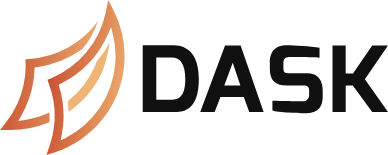

# ¿Qué es Dask?

- Librería de Python para cómputo paralelo y distribuido.
- Escala código de NumPy, Pandas y funciones normales de Python.
- Permite usar múltiples núcleos o incluso clústeres.
- Pensado para:
  - Datos más grandes que la memoria.
  - Cálculo intensivo.
  - Flujos de trabajo personalizados.
- Fácil de instalar:
  - `pip install dask[complete]` (hay otras como [array] o [dataframe])

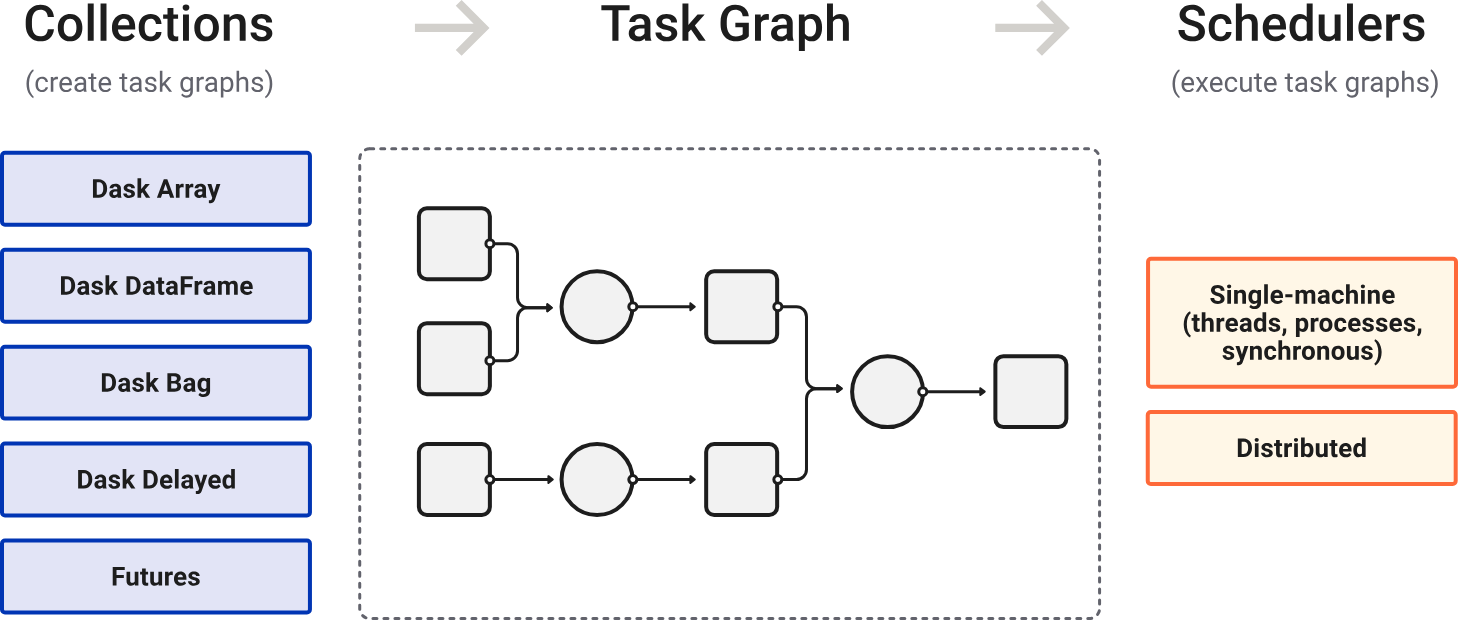

In [1]:
from dask.distributed import LocalCluster
cluster = LocalCluster()          # Fully-featured local Dask cluster
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 15.41 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46797,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36243,Total threads: 3
Dashboard: http://127.0.0.1:43451/status,Memory: 3.85 GiB
Nanny: tcp://127.0.0.1:45501,


In [12]:
import dask.array as da
from dask import delayed

a = da.random.random((100_000, 100_000), chunks=(5_000, 5_000))
a

dask.array<random_sample, shape=(100000, 100000), dtype=float64, chunksize=(5000, 5000), chunktype=numpy.ndarray>

In [ ]:
b = a + a.T
c = b[::2, :].mean(axis=1)
c

dask.array<mean_agg-aggregate, shape=(50000,), dtype=float64, chunksize=(2500,), chunktype=numpy.ndarray>

In [ ]:
c.compute()

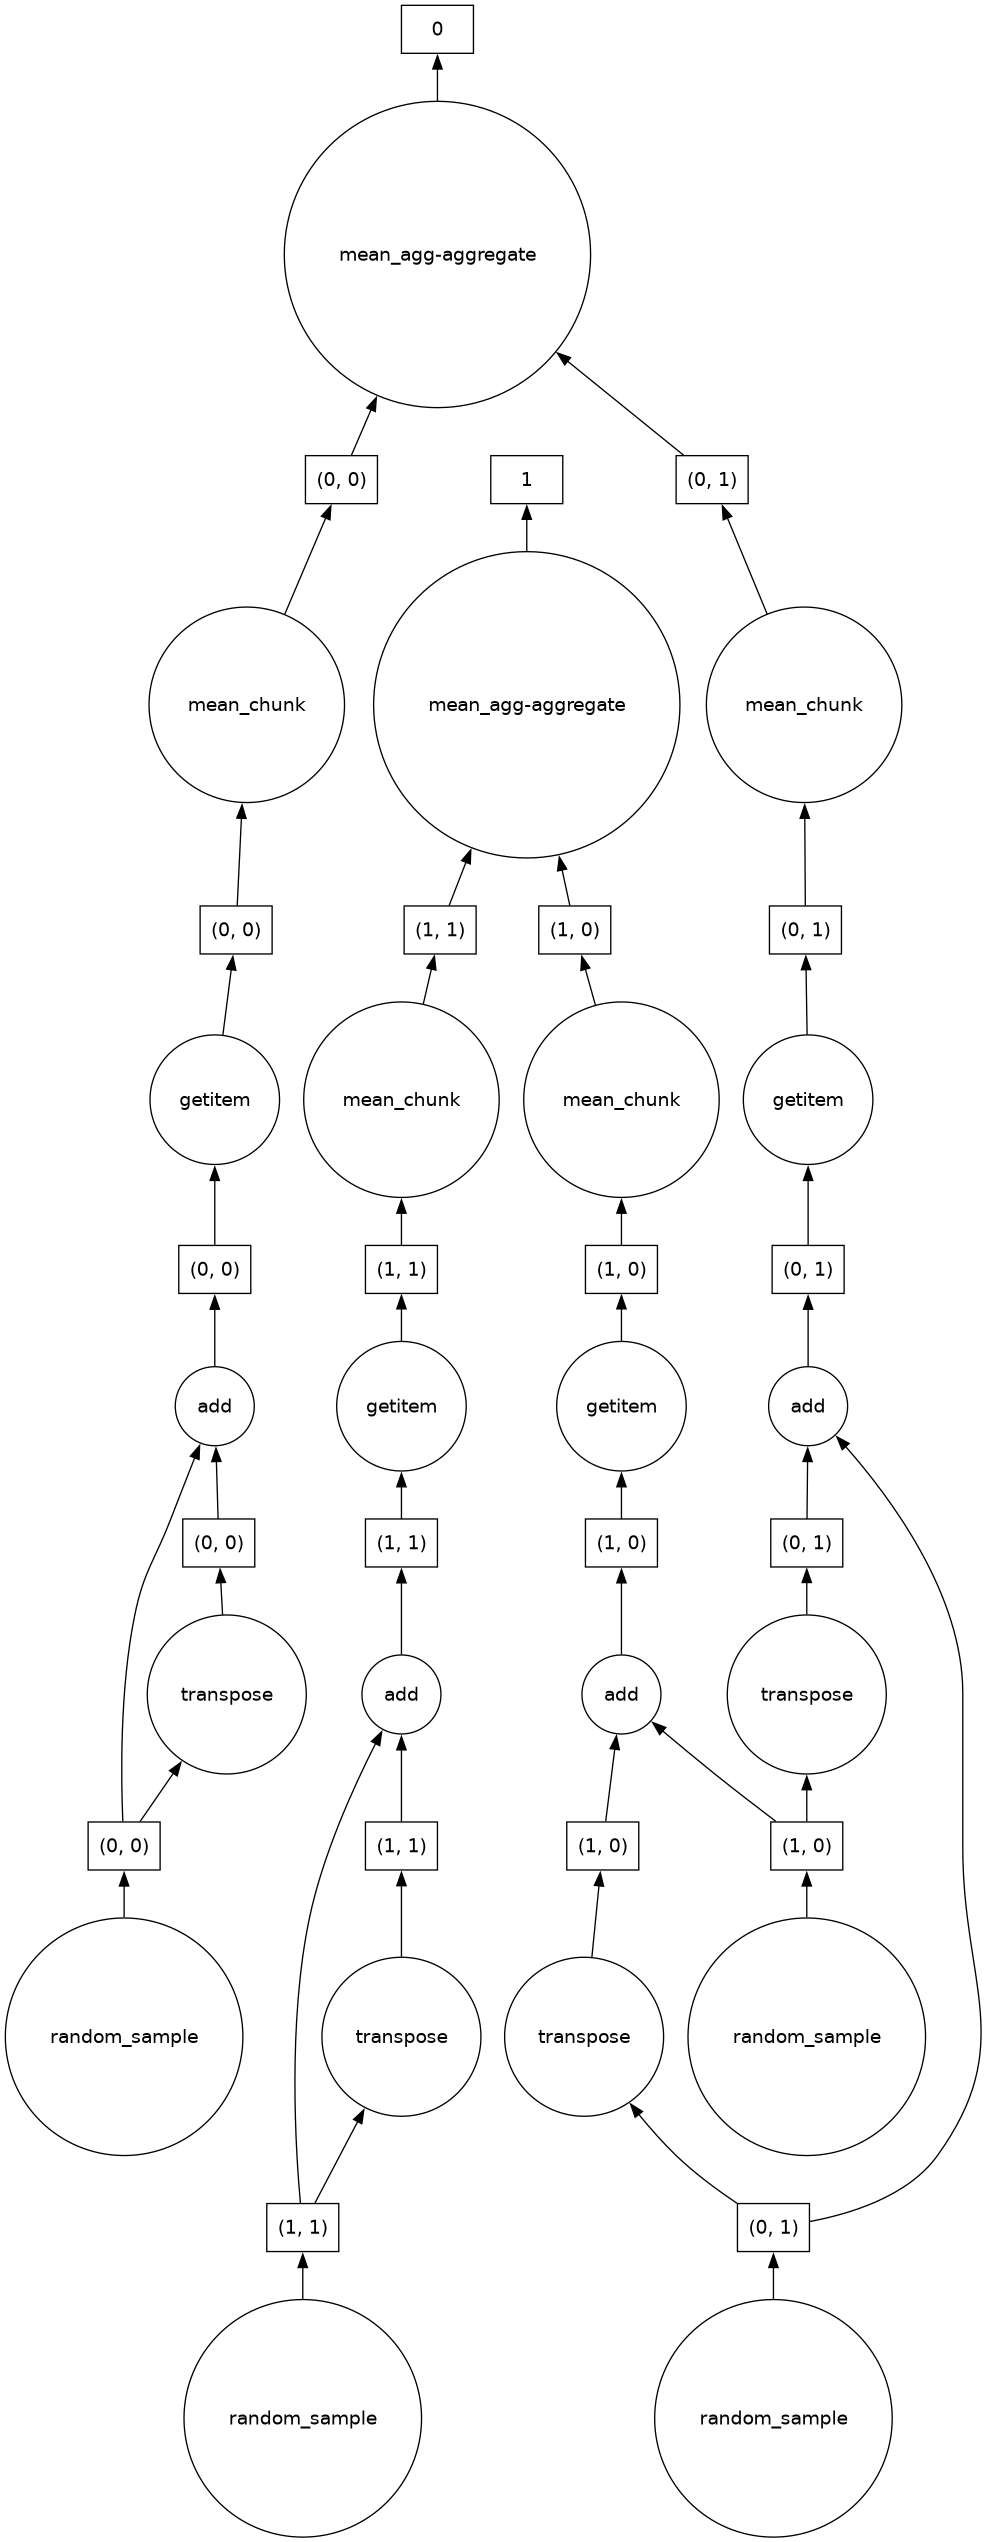

In [ ]:
c.visualize()

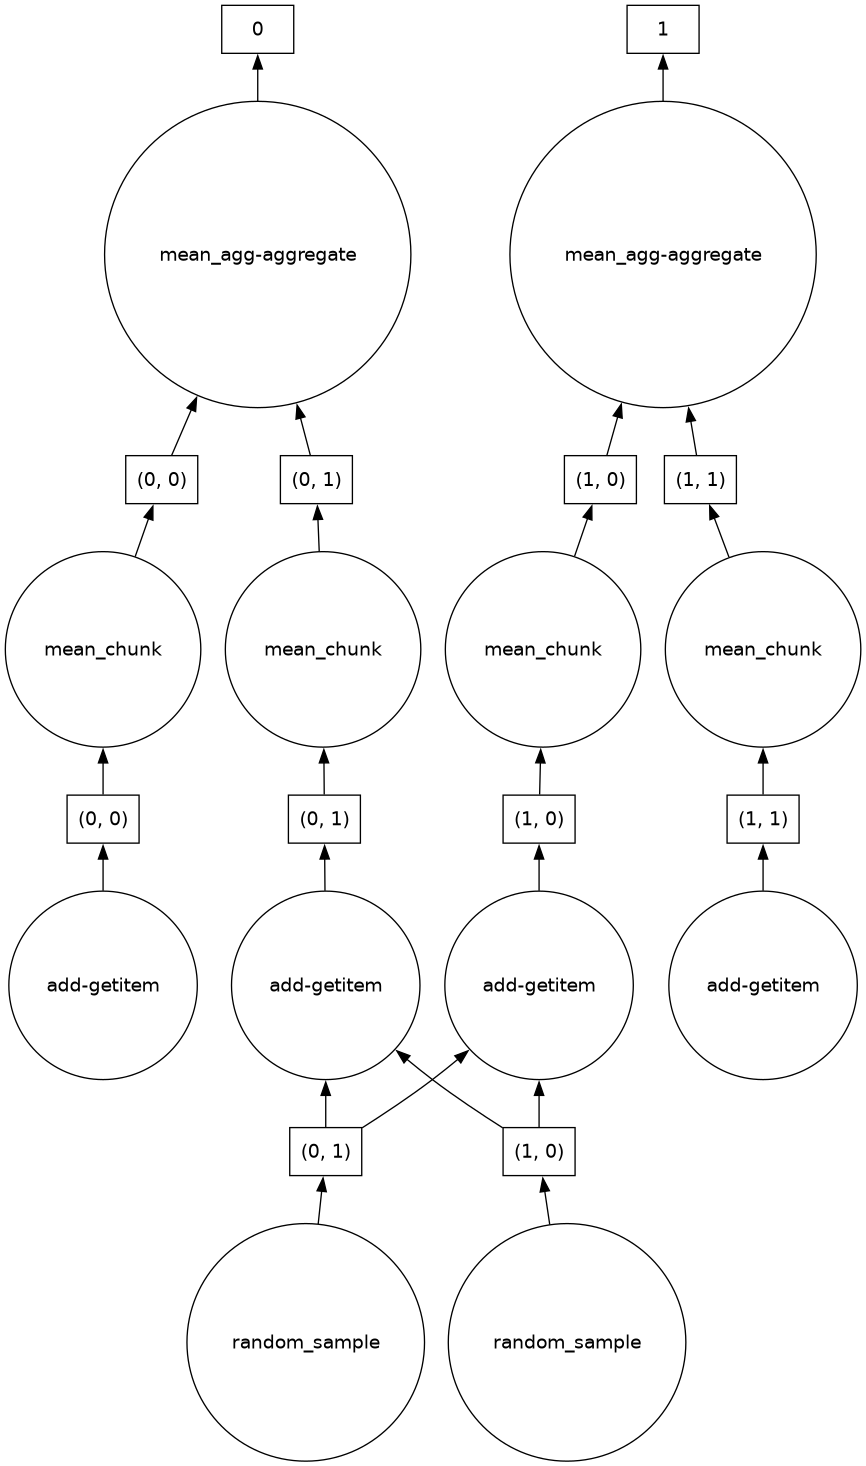

In [ ]:
c.visualize(optimize_graph=True)